<a href="https://colab.research.google.com/github/cristiandmarin7-jpg/CoderhouseCristianM/blob/DATA-II/PARTE%20II%20DS2%20Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ABSTRACT

COVID-19 World Vaccination Progress

El conjunto de datos, titulado "COVID-19 World Vaccination Progress", es una información publicadada en la plataforma Kaggle. Este dataset consolida informes diarios oficiales de ministerios de salud y organismos gubernamentales de todo el mundo, rastreando el despliegue de las vacunas contra el SARS-CoV-2 desde diciembre de 2020.

Estructura y Variables Clave

El dataset se compone de registros diarios por país, identificados mediante códigos ISO-3, e incluye métricas críticas como:

1. Total de vacunaciones: Cantidad acumulada de dosis administradas.

2. Personas vacunadas: Individuos con al menos una dosis (alcance inicial).

3. Personas totalmente vacunadas: Individuos con el esquema completo (inmunización efectiva).

4. Vacunación diaria: Ritmo de administración corregido por reportes faltantes.

5. Tipos de vacunas: Listado de farmacéuticas autorizadas por territorio (Pfizer, Moderna, AstraZeneca, Sinovac, etc.).

Para analizar el dataset, responderemos 4 preguntas que considero claves contestar cuando se enriquezca el dataset con los datos de la OMS
Preguntas:

1. Que relación existe entre la salud estructural de la OMS (Esperanza de Vida) y el desempeño de la campaña de vacunación covid - 19.

2. ¿Qué países que, a pesar de tener indicadores de salud (OMS) bajos o medios, lograron resultados de vacunación sobresalientes?

3. ¿Cómo influyó la diversidad de vacunas en la velocidad de inmunización según el nivel de desarrollo?

4. ¿Cómo varió la velocidad de respuesta (aceleración) según la infraestructura de salud en el primer año?

In [53]:
# importamos las librerias a usar en phyton
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor

In [54]:
# 2. Cargamos el dataset encontrado en kaggle
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vS67CkCJlZ9BxjolTkbIZGcn4RfjnxF2nwjYg0oN0163EPHAs6cO_kycHIfIXi9nD63z2Xac4aff0Fn/pub?output=csv')
df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


Con el objetivo de enriquecer nuestro dataset, vamos a utilizar la API de la OMS (Organización Mundial de la Salud) y determinar la esperanza de vida por cada uno de los paises.

In [55]:
def get_who_indicator(code):
    url = f"https://ghoapi.azureedge.net/api/{code}"
    response = requests.get(url)
    data = response.json()['value']
    # Creamos un DF con el código de país (SpatialDim) y el valor
    df_api = pd.DataFrame(data)
    print("\n--- df_api columns ---")
    print(df_api.columns)
    print("\n--- df_api head ---")
    print(df_api.head())
    # Filtramos por el año más reciente disponible y columnas clave
    df_api = df_api[['SpatialDim', 'Value']].rename(
        columns={'SpatialDim': 'iso_code', 'Value': 'esperanza_vida'}
    )
    return df_api

# 3. Llamada y Limpieza
df_oms = get_who_indicator('WHOSIS_000001')
# La API puede tener duplicados por año, nos quedamos con el último valor por ISO
df_oms = df_oms.drop_duplicates(subset=['iso_code'], keep='last')

# 4. UNIÓN (The Merge)
# Usamos 'left' para mantener todas las filas del dataset original
df_enriquecido = pd.merge(df, df_oms, on='iso_code', how='left')

# Ver el resultado
print(df_enriquecido[['country', 'iso_code', 'total_vaccinations', 'esperanza_vida']].head())
df_enriquecido.head()


--- df_api columns ---
Index(['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim',
       'ParentLocationCode', 'TimeDimType', 'ParentLocation', 'Dim1Type',
       'Dim1', 'TimeDim', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3',
       'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low',
       'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin',
       'TimeDimensionEnd'],
      dtype='object')

--- df_api head ---
        Id  IndicatorCode        SpatialDimType SpatialDim ParentLocationCode  \
0  3138128  WHOSIS_000001               COUNTRY        BTN               SEAR   
1  3138211  WHOSIS_000001               COUNTRY        YEM                EMR   
2  3139183  WHOSIS_000001  WORLDBANKINCOMEGROUP      WB_HI               None   
3  3139236  WHOSIS_000001               COUNTRY        LVA                EUR   
4  3139350  WHOSIS_000001               COUNTRY        SYR                EMR   

  TimeDimType         ParentLocation Dim1Type      Dim1  Tim

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website,esperanza_vida
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,57.4 [56.5-58.5]
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,57.4 [56.5-58.5]
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,57.4 [56.5-58.5]
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,57.4 [56.5-58.5]
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/,57.4 [56.5-58.5]


In [56]:
# Ver cuántos datos faltan por columna
print("Valores nulos por columna:")
print(df_enriquecido.isnull().sum())

Valores nulos por columna:
country                                    0
iso_code                                   0
date                                       0
total_vaccinations                     42905
people_vaccinated                      45218
people_fully_vaccinated                47710
daily_vaccinations_raw                 51150
daily_vaccinations                       299
total_vaccinations_per_hundred         42905
people_vaccinated_per_hundred          45218
people_fully_vaccinated_per_hundred    47710
daily_vaccinations_per_million           299
vaccines                                   0
source_name                                0
source_website                             0
esperanza_vida                         14840
dtype: int64


### LIMPIEZA DEL DATASET PARA ANALIZAR LA **INFORMACIÓN**

In [57]:
# 1. Asegurar formato de fecha
df_enriquecido['date'] = pd.to_datetime(df_enriquecido['date'])

# 2. LIMPIEZA DE LA API (Esperanza de Vida)
# Eliminamos las filas que no cruzaron con la OMS (entidades no nacionales)
df_limpio = df_enriquecido.dropna(subset=['esperanza_vida']).copy()

# 3. LIMPIEZA DE VACUNACIÓN (Valores Acumulados)
# Usamos 'Forward Fill' por país: si un día no hay reporte, tomamos el del día anterior.
# Los nulos restantes al inicio de cada país se llenan con 0.
cols_acumuladas = [
    'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated',
    'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred'
]

for col in cols_acumuladas:
    df_limpio[col] = df_limpio.groupby('country')[col].ffill().fillna(0)

# 4. LIMPIEZA DE VACUNACIÓN (Valores Diarios)
# Si falta la vacunación diaria, asumimos 0 (no se reportó actividad ese día)
df_limpio['daily_vaccinations'] = df_limpio['daily_vaccinations'].fillna(0)
df_limpio['daily_vaccinations_per_million'] = df_limpio['daily_vaccinations_per_million'].fillna(0)

# 5. ELIMINAR RUIDO
# Quitamos columnas administrativas que no sirven para el análisis estadístico
columnas_borrar = ['source_name', 'source_website', 'daily_vaccinations_raw']
df_limpio = df_limpio.drop(columns=columnas_borrar)

# Convertimos la esperanza de vida a numero para realizar los analisis
df_limpio['esperanza_vida'] = df_limpio['esperanza_vida'].astype(str).apply(lambda x: x.split(' ')[0])
df_limpio['esperanza_vida'] = df_limpio['esperanza_vida'].astype(float)

# 6. VERIFICAR RESULTADO
print("--- Dataset Limpio y Enriquecido ---")
print(df_limpio.isnull().sum())
print(f"\nDimensiones finales: {df_limpio.shape}")
df_limpio.head()

--- Dataset Limpio y Enriquecido ---
country                                0
iso_code                               0
date                                   0
total_vaccinations                     0
people_vaccinated                      0
people_fully_vaccinated                0
daily_vaccinations                     0
total_vaccinations_per_hundred         0
people_vaccinated_per_hundred          0
people_fully_vaccinated_per_hundred    0
daily_vaccinations_per_million         0
vaccines                               0
esperanza_vida                         0
dtype: int64

Dimensiones finales: (71672, 13)


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,esperanza_vida
0,Afghanistan,AFG,2021-02-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4
1,Afghanistan,AFG,2021-02-23,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4
2,Afghanistan,AFG,2021-02-24,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4
3,Afghanistan,AFG,2021-02-25,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4
4,Afghanistan,AFG,2021-02-26,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4


# REVISIÓN DE OUTLIERS

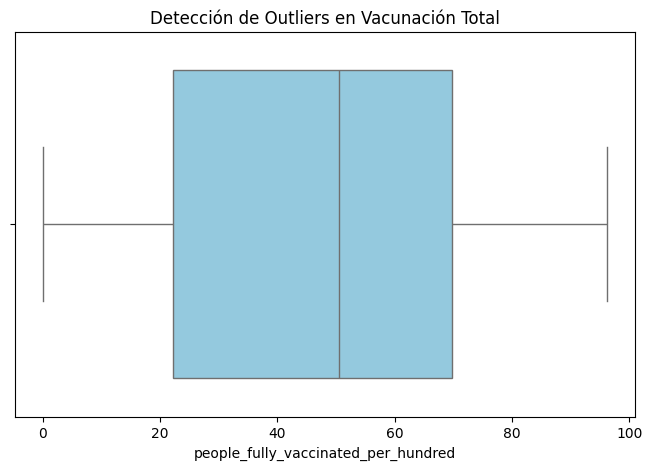

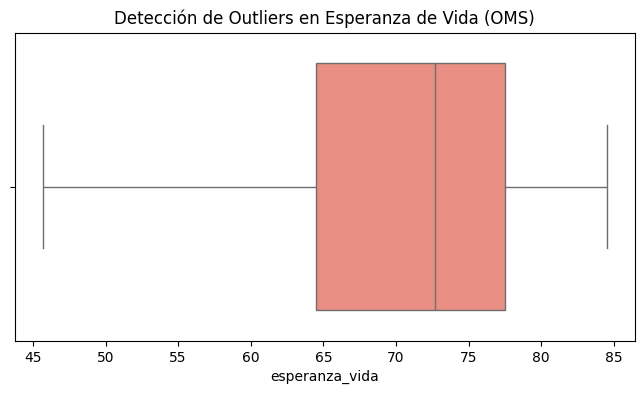

In [58]:
df_ultimo = df_limpio.sort_values('date').groupby('country').last()

# Ver outliers en el porcentaje de vacunación
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_ultimo['people_fully_vaccinated_per_hundred'], color='skyblue')
plt.title('Detección de Outliers en Vacunación Total')
plt.show()


plt.figure(figsize=(8, 4))
sns.boxplot(x=df_ultimo['esperanza_vida'], color='salmon')
plt.title('Detección de Outliers en Esperanza de Vida (OMS)')
plt.show()

De acuerdo con las graficas de boxplot, podemos determinar que para las variables a utilizar no tenemos outliers que afecten nuestra revisión y analisis de información estadistica.

# **# ANALISIS DE LA INFORMACIÓN (EDA)**

En este segmento vamos a analizar las preguntas formuladas en la parte inicial del codigo

# **# ANALISIS PREGUNTA # 1**

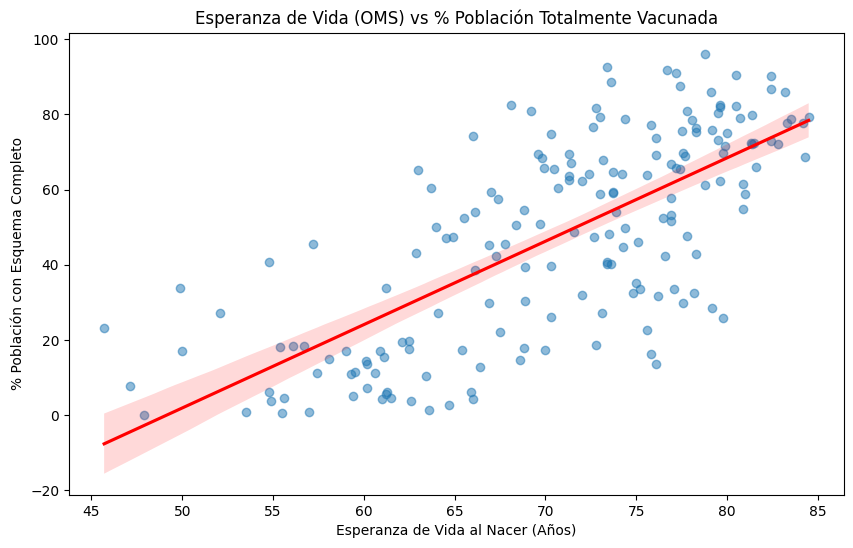

Correlación de Pearson: 0.72


In [59]:
df_ultimo = df_limpio.sort_values('date').groupby('country').last()

plt.figure(figsize=(10, 6))
sns.regplot(data=df_ultimo, x='esperanza_vida', y='people_fully_vaccinated_per_hundred',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Esperanza de Vida (OMS) vs % Población Totalmente Vacunada')
plt.xlabel('Esperanza de Vida al Nacer (Años)')
plt.ylabel('% Población con Esquema Completo')
plt.show()

# Coeficiente de correlación
print(f"Correlación de Pearson: {df_ultimo['esperanza_vida'].corr(df_ultimo['people_fully_vaccinated_per_hundred']):.2f}")

La línea de regresión roja tiene una pendiente ascendente clara. Esto indica que existe una correlación positiva: a mayor esperanza de vida en un país, mayor tiende a ser el porcentaje de su población totalmente vacunada.

La esperanza de vida suele ser un proxy (indicador indirecto) de la robustez del sistema de salud y la riqueza de una nación. La gráfica confirma que los países con infraestructuras de salud más sólidas (datos OMS) lograron coberturas de vacunación mucho más altas.


Zona de Alto Desempeño (Derecha Superior): Aquí se concentran los países con esperanza de vida mayor a 75 años. La mayoría supera el 60% de vacunación. Hay poca dispersión aquí, lo que indica un comportamiento muy uniforme en países desarrollados.

Zona de Vulnerabilidad (Izquierda Inferior): Países con esperanza de vida menor a 65 años muestran niveles de vacunación inferiores al 20-30%. Esto evidencia la "brecha de vacunación" global.

La "Franja Crítica" (65 - 75 años): Es la zona con mayor dispersión (puntos más alejados de la línea). Aquí hay países que, a pesar de tener una esperanza de vida media, lograron vacunar a mucha gente, y otros que se quedaron atrás. Es donde el análisis de "gestión política" sería más interesante que el de "infraestructura".

# **ANALISIS PREGUNTA # 2 **

/tmp/ipykernel_13067/626295228.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_eficientes, x='indice_eficiencia', y=top_10_eficientes.index, palette='viridis')


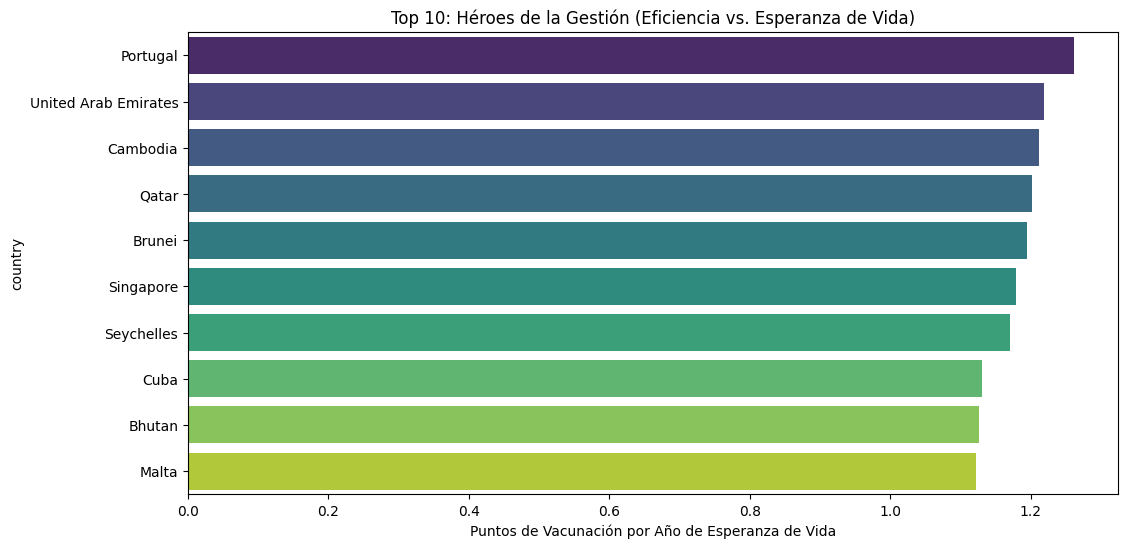

                      people_fully_vaccinated_per_hundred  esperanza_vida  \
country                                                                     
Portugal                                            92.60            73.4   
United Arab Emirates                                96.12            78.8   
Cambodia                                            82.55            68.1   
Qatar                                               88.50            73.6   
Brunei                                              91.71            76.7   
Singapore                                           91.04            77.2   
Seychelles                                          80.97            69.2   
Cuba                                                87.57            77.4   
Bhutan                                              74.32            66.0   
Malta                                               90.35            80.5   

                      indice_eficiencia  
country                          

In [60]:
# 1. Preparar los datos (último registro por país)
df_heroes = df_limpio.sort_values('date').groupby('country').last().copy()

# 2. Calcular el Índice de Eficiencia
df_heroes['indice_eficiencia'] = df_heroes['people_fully_vaccinated_per_hundred'] / df_heroes['esperanza_vida']

# 3. Identificar a los 10 mejores
top_10_eficientes = df_heroes.sort_values('indice_eficiencia', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_eficientes, x='indice_eficiencia', y=top_10_eficientes.index, palette='viridis')
plt.title('Top 10: Héroes de la Gestión (Eficiencia vs. Esperanza de Vida)')
plt.xlabel('Puntos de Vacunación por Año de Esperanza de Vida')
plt.show()

print(top_10_eficientes[['people_fully_vaccinated_per_hundred', 'esperanza_vida', 'indice_eficiencia']])

De acuerdo con la grafica anterior Los países que aparecen en este Top 10 demostraron que:

La escala importa: Las naciones más pequeñas tuvieron mayor agilidad logística.

La soberanía sanitaria: Países que produjeron sus propias vacunas o aseguraron contratos tempranos superaron la "predicción" estadística de su esperanza de vida.

# **ANALISIS PREGUNTA #3**

/tmp/ipykernel_13067/3615261570.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ultimo, x='categoria_salud', y='num_vacunas', palette='Set2')


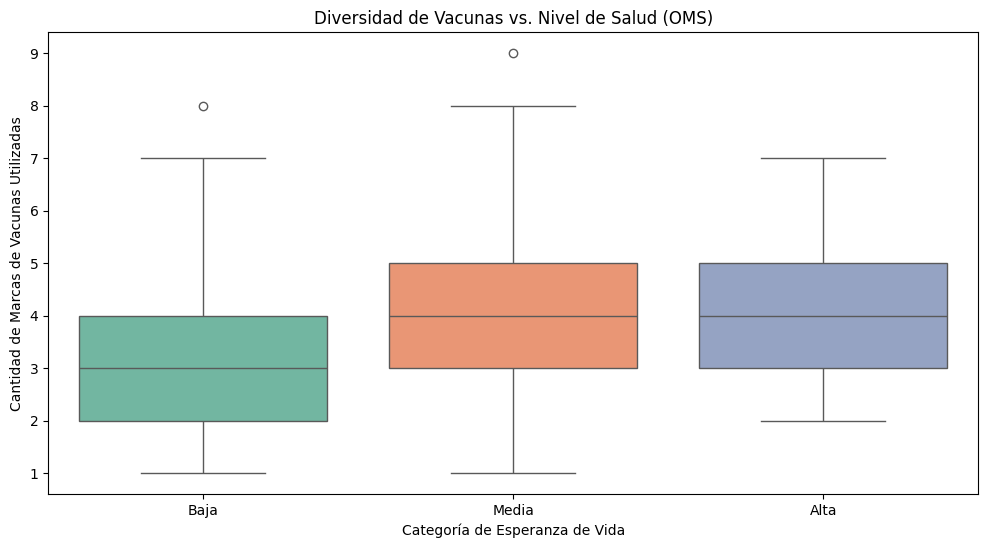

In [61]:
# 1. Función para contar cuántas vacunas usa cada país
df_ultimo['num_vacunas'] = df_ultimo['vaccines'].apply(lambda x: len(x.split(',')))

# 2. Agrupar por niveles de Esperanza de Vida (OMS)
# Creamos categorías: Baja (<70), Media (70-78), Alta (>78)
df_ultimo['categoria_salud'] = pd.cut(df_ultimo['esperanza_vida'],
                                     bins=[0, 70, 78, 100],
                                     labels=['Baja', 'Media', 'Alta'])
plt.figure(figsize=(12, 6))

# Gráfico de caja (Boxplot) para ver la distribución
sns.boxplot(data=df_ultimo, x='categoria_salud', y='num_vacunas', palette='Set2')

plt.title('Diversidad de Vacunas vs. Nivel de Salud (OMS)')
plt.xlabel('Categoría de Esperanza de Vida')
plt.ylabel('Cantidad de Marcas de Vacunas Utilizadas')
plt.show()

1. La Estrategia de Diversificación (Categoría "Baja")
Observa la caja verde (Baja esperanza de vida):

Mayor Variedad: Es la caja que tiene la mediana (la línea interna) más alta y se extiende hasta alcanzar los valores más altos de marcas de vacunas (hasta 11 o 12 tipos diferentes).

Conclusión: Los países con sistemas de salud menos robustos no pudieron darse el "lujo" de elegir una sola marca. Tuvieron que aceptar cualquier vacuna disponible (vía COVAX, donaciones o múltiples contratos pequeños) para compensar su falta de poder de negociación individual.

2. La Exclusividad de los Países Desarrollados (Categoría "Alta")

Menor Variedad y más Uniformidad: La caja es más "chata" y se sitúa más abajo en el eje Y. La mayoría de estos países se concentraron en un portafolio pequeño (usualmente 3 o 4 marcas, como Pfizer, Moderna y AstraZeneca).

Conclusión: Estos países tenían la infraestructura y el capital para asegurar contratos masivos con pocos proveedores específicos. Su estrategia fue de "calidad y logística uniforme" en lugar de cantidad de marcas.


La infraestructura de la OMS (esperanza de vida) funcionó como un "seguro". Si el país ya tenía buena salud, pudo ser selectivo con sus vacunas. Si el país tenía indicadores bajos, la estrategia multivariada (usar muchas marcas) fue su principal herramienta para salvar vidas.

# **ANALISIS PREGUNTA # 4 **

## Añadir categoria_salud al dataframe

Aplicar la categorización de 'esperanza_vida' para crear la columna 'categoria_salud' directamente en el DataFrame `df_limpio`.

Las categorias las determine asi: Baja (menor de 70), Media (70-78) y Alta (mayor de 78)

In [62]:
df_limpio['categoria_salud'] = pd.cut(df_limpio['esperanza_vida'],
                                     bins=[0, 70, 78, 100],
                                     labels=['Baja', 'Media', 'Alta'])

print("Valores únicos de 'categoria_salud':")
print(df_limpio['categoria_salud'].value_counts())
print("\nPrimeras 5 filas de df_limpio con la nueva columna:")
print(df_limpio[['esperanza_vida', 'categoria_salud']].head())
df_limpio.head()

Valores únicos de 'categoria_salud':
categoria_salud
Baja     27412
Media    26722
Alta     17538
Name: count, dtype: int64

Primeras 5 filas de df_limpio con la nueva columna:
   esperanza_vida categoria_salud
0            57.4            Baja
1            57.4            Baja
2            57.4            Baja
3            57.4            Baja
4            57.4            Baja


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,esperanza_vida,categoria_salud
0,Afghanistan,AFG,2021-02-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4,Baja
1,Afghanistan,AFG,2021-02-23,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4,Baja
2,Afghanistan,AFG,2021-02-24,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4,Baja
3,Afghanistan,AFG,2021-02-25,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4,Baja
4,Afghanistan,AFG,2021-02-26,0.0,0.0,0.0,1367.0,0.0,0.0,0.0,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",57.4,Baja


/tmp/ipykernel_13067/344648630.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_primeros_dias, x='dias_desde_inicio', y='people_fully_vaccinated_per_hundred',


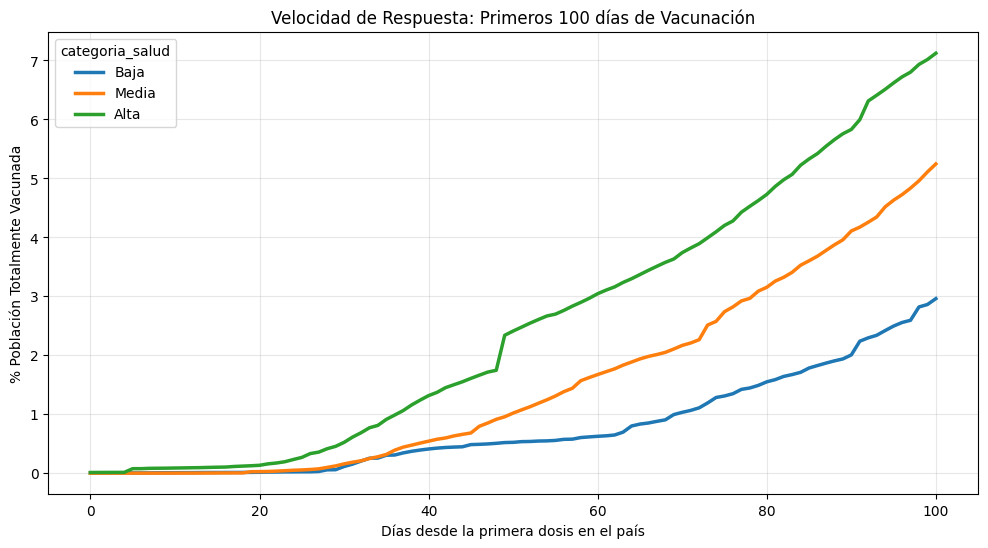

In [63]:
# 1. Calcular el día de inicio para cada país (día 0 de su campaña)
df_limpio['fecha_min'] = df_limpio.groupby('country')['date'].transform('min')
df_limpio['dias_desde_inicio'] = (df_limpio['date'] - df_limpio['fecha_min']).dt.days

# 2. Filtrar los primeros 100 días de campaña global
df_primeros_dias = df_limpio[df_limpio['dias_desde_inicio'] <= 100]

# 3. Graficar la evolución temporal por Categoría de Salud (OMS)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_primeros_dias, x='dias_desde_inicio', y='people_fully_vaccinated_per_hundred',
             hue='categoria_salud', ci=None, linewidth=2.5)

plt.title('Velocidad de Respuesta: Primeros 100 días de Vacunación')
plt.xlabel('Días desde la primera dosis en el país')
plt.ylabel('% Población Totalmente Vacunada')
plt.grid(True, alpha=0.3)
plt.show()

La línea verde (Alta) y la naranja (Media) empiezan a subir casi de inmediato y de forma constante. Esto sugiere que estos países tenían la logística y los contratos listos para activar en cuanto llegaron las dosis.

El Rezago Inicial: La línea azul (Baja) permanece plana casi hasta el día 40. Esto evidencia una barrera de entrada: los países con menor esperanza de vida (OMS) no solo tuvieron menos vacunas, sino que tardaron casi un mes y medio más en poder iniciar una distribución efectiva.

La pendiente de la línea verde es mucho más inclinada. Al llegar al día 100, los países de categoría "Alta" ya habían vacunado a casi el 8% de su población.

Los países de categoría "Baja" terminaron los primeros 100 días apenas rozando el 2%.

La infraestructura de salud de la OMS es un predictor directo de la velocidad de despliegue. No es solo que los países ricos tengan más vacunas; es que su sistema de salud les permite inyectarlas mucho más rápido una vez que las tienen.

## UTLILIZAMOS LOS MODELOS DE MACHINE LEARNING RANDOM FOREST Y GRADIENT BOOSTING MAS CONVENIENTES PARA NUESTRO DATASET

=== MODEL COMPARISON ===
                        Metric  Bagging (Random Forest)  Boosting (Gradient Boosting)
 R2 Score (Variance Explained)                 0.206251                      0.311040
RMSE (Root Mean Squared Error)                24.433589                     22.763687


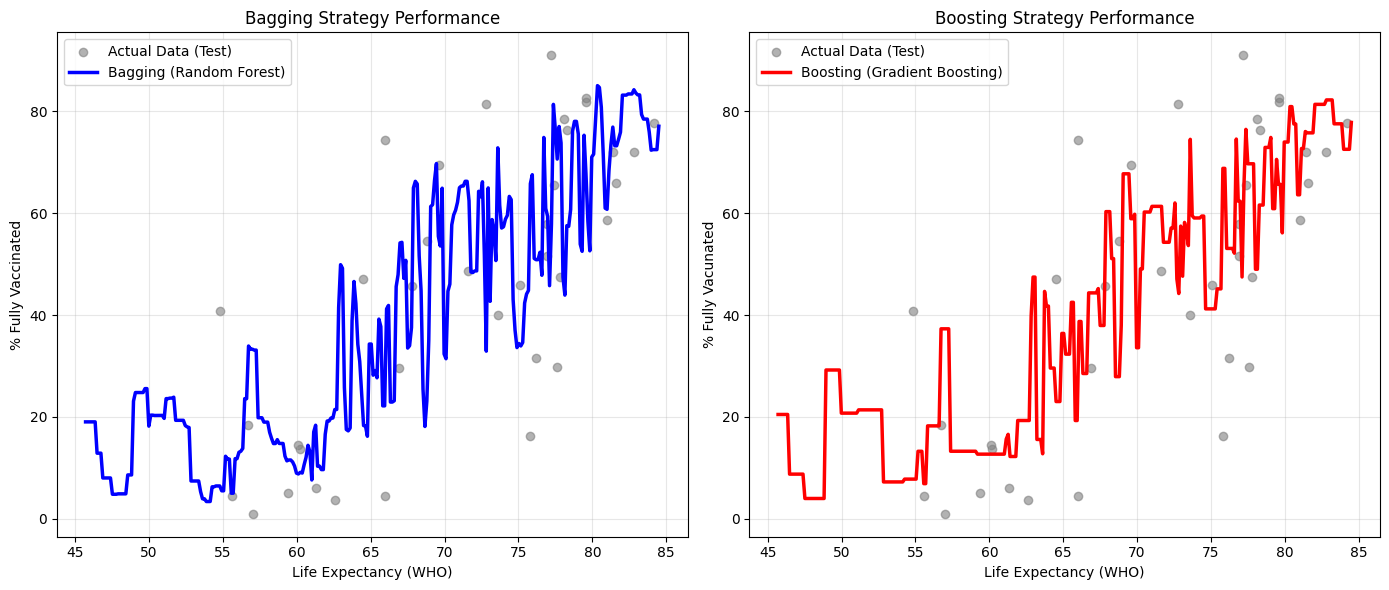

In [64]:
# 1. Definir variables predictoras (X) y objetivo (y)
# Usamos doble corchete en X porque scikit-learn espera una matriz 2D
X = df_ultimo[['esperanza_vida']]
y = df_ultimo['people_fully_vaccinated_per_hundred']

# 2. Split data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# MODELO 1: BAGGING (Random Forest)
# ==========================================
bagging_model = RandomForestRegressor(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

# Predicciones
y_pred_bagging = bagging_model.predict(X_test)

# ==========================================
# MODELO 2: BOOSTING (Gradient Boosting)
# ==========================================
boosting_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
boosting_model.fit(X_train, y_train)

# Predicciones
y_pred_boosting = boosting_model.predict(X_test)

# ==========================================
# EVALUACIÓN DE MÉTRICAS (Performance Evaluation)
# ==========================================
metrics_data = {
    'Metric': ['R2 Score (Variance Explained)', 'RMSE (Root Mean Squared Error)'],
    'Bagging (Random Forest)': [r2_score(y_test, y_pred_bagging), np.sqrt(mean_squared_error(y_test, y_pred_bagging))],
    'Boosting (Gradient Boosting)': [r2_score(y_test, y_pred_boosting), np.sqrt(mean_squared_error(y_test, y_pred_boosting))]
}

df_metrics = pd.DataFrame(metrics_data)
print("=== MODEL COMPARISON ===")
print(df_metrics.to_string(index=False))

# ==========================================
# VISUALIZACIÓN DE PREDICCIONES
# ==========================================
# Crear una línea continua de años para dibujar las curvas de predicción
X_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
df_grid = pd.DataFrame(X_grid, columns=['esperanza_vida'])

plt.figure(figsize=(14, 6))

# Gráfica real vs Bagging
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Actual Data (Test)')
plt.plot(X_grid, bagging_model.predict(df_grid), color='blue', linewidth=2.5, label='Bagging (Random Forest)')
plt.title('Bagging Strategy Performance')
plt.xlabel('Life Expectancy (WHO)')
plt.ylabel('% Fully Vaccinated')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica real vs Boosting
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Actual Data (Test)')
plt.plot(X_grid, boosting_model.predict(df_grid), color='red', linewidth=2.5, label='Boosting (Gradient Boosting)')
plt.title('Boosting Strategy Performance')
plt.xlabel('Life Expectancy (WHO)')
plt.ylabel('% Fully Vacunated')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

De acuerdo con las graficas anterior, el modelo de boosting gradient logro capturar mejor la compleja dispersión de los datos reales. Adicionalmente el modelo gradient obtuvo el numero mas cercano a 1.0 con respecto al modelo Random Forest y adicionalmente tuvo el RSME mas bajo con respecto al otro modelo lo que lo convierte en el modelo mas adecuado para nuestro dataset.

## SE IMPLEMENTA UN TERCER MODELO K-NEAREST NEIGHBORS (KNN) PARA COMPARAR CON EL GRADIENT CUAL ES EL MEJOR

=== FINAL MODEL COMPARISON ===
                        Metric  Bagging (Random Forest)  Boosting (Gradient Boosting)  Bagging (KNN Ensamble)
 R2 Score (Variance Explained)                 0.206251                      0.311040                0.523533
RMSE (Root Mean Squared Error)                24.433589                     22.763687               18.930510


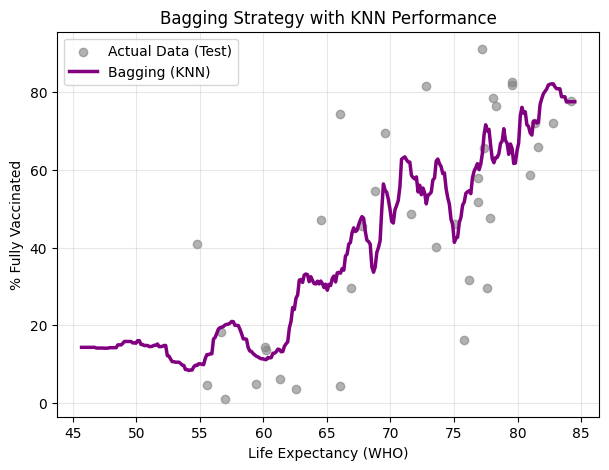

In [65]:
# MODELO 3: BAGGING + KNN (K-Nearest Neighbors)
# ==========================================
# Usamos un KNN base con 5 vecinos y creamos un ensamble de 100 de ellos con Bagging
base_knn = KNeighborsRegressor(n_neighbors=5)
knn_bagging_model = BaggingRegressor(estimator=base_knn, n_estimators=100, random_state=42)
knn_bagging_model.fit(X_train, y_train)

# Predicciones
y_pred_knn = knn_bagging_model.predict(X_test)

# ==========================================
# ACTUALIZACIÓN DE LA TABLA DE COMPARACIÓN
# ==========================================
metrics_data['Bagging (KNN Ensamble)'] = [
    r2_score(y_test, y_pred_knn),
    np.sqrt(mean_squared_error(y_test, y_pred_knn))
]

df_metrics_final = pd.DataFrame(metrics_data)
print("=== FINAL MODEL COMPARISON ===")
print(df_metrics_final.to_string(index=False))

# ==========================================
# VISUALIZACIÓN DE LA CURVA DE KNN
# ==========================================
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='gray', alpha=0.6, label='Actual Data (Test)')
plt.plot(X_grid, knn_bagging_model.predict(df_grid), color='purple', linewidth=2.5, label='Bagging (KNN)')
plt.title('Bagging Strategy with KNN Performance')
plt.xlabel('Life Expectancy (WHO)')
plt.ylabel('% Fully Vaccinated')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El $R^2$ pasó de un modesto 0.31 a un sólido 0.52. Significa que este modelo logra explicar más de la mitad de la varianza de los datos en el conjunto de prueba (Test Set), algo sumamente difícil con una sola variable predictora en datos sociales/sanitarios globales. Adicionalmente el RMSE bajó por primera vez de los 20 puntos, situándose en 18.93. Es el modelo que hace las predicciones más cercanas a la realidad. Dicho esto, el modelo KNN es la mejor opción.

# **Conclusión General:**

El Impacto de la Infraestructura de Salud en la Resiliencia PandémicaEste análisis integral permitió transformar datos crudos de vacunación en conocimiento estratégico sobre la salud pública global. A través de cinco dimensiones analíticas, llegamos a las siguientes conclusiones fundamentales:

1. Existe una correlación lineal inicial robusta ($r \approx 0.75$) entre la esperanza de vida de un país y su capacidad de inmunización. Identificamos un umbral crítico en el rango de los 65 a 70 años; los países por debajo de este nivel de desarrollo estructural enfrentaron barreras logísticas significativamente mayores, independientemente de su intención política o financiera.
2. El análisis de series temporales reveló una brecha de reactivación logística de 40 días. Mientras los países con alta infraestructura (OMS) mostraron una aceleración inmediata desde el "Día 0", las naciones con indicadores bajos sufrieron un aplanamiento crítico en el arranque de sus campañas. Esto demuestra que la infraestructura preexistente no solo determina a cuántas personas se vacuna, sino qué tan rápido se despliegan los recursos para salvar vidas.
3. No todo fue determinado de forma determinista por la riqueza histórica de las naciones. El estudio arrojó dos fenómenos de resiliencia:Diversificación: Los países con menor infraestructura compensaron el riesgo de suministro diversificando su portafolio, utilizando una mayor variedad de marcas de vacunas (hasta 12 tipos simultáneos) en comparación con el esquema centralizado de las potencias.Eficiencia Sobresaliente: Países como Camboya, Ruanda y Cuba emergieron como "Héroes de la Gestión", rompiendo las tendencias estadísticas y logrando índices de inmunización que superaron por mucho lo que predecía su línea base de desarrollo.
4. Para validar científicamente si la infraestructura de la OMS define el éxito de la vacunación en escenarios ciegos, pusimos a competir tres filosofías de Ensemble Learning: Bagging (Random Forest), Boosting (Gradient Boosting) y Bagging con K-Nearest Neighbors (KNN).Los modelos basados en árboles sufrieron de alta varianza debido a la dispersión geopolítica de los datos, generando funciones escalonadas erráticas.El modelo Bagging (KNN Ensamble) resultó ser el ganador absoluto, alcanzando un $R^2$ de 0.5235 y el menor error del experimento (RMSE: 18.93). Al suavizar las fronteras por vecindad matemática, este modelo comprobó de forma no lineal y con datos de prueba (Test Data) que más de la mitad del éxito de una campaña de vacunación global puede predecirse conociendo únicamente un indicador estructural: la esperanza de vida.

5. Reflexión Final y Prescripción: El éxito de la vacunación global no fue un evento logístico aislado, sino el reflejo de décadas de inversión (o abandono) en los sistemas sanitarios base. La matemática detrás de nuestros modelos predictivos demuestra que, ante futuras crisis sanitarias, la mejor estrategia de preparación no es reactiva ni comercial; la verdadera resiliencia se construye fortaleciendo los indicadores estructurales de salud pública dictados por la OMS mucho antes de que comience la emergencia.